#### Inputs

In [15]:
# Bibliotecas
from brukeropus import read_opus
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import tempfile
import optuna
import boto3
import random
import os

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Configurações
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mudança no display
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Usa as credenciais já configuradas no seu ambiente AWS CLI
session = boto3.Session(region_name="us-east-1")
s3 = session.client("s3")


def avaliar_modelos_espectrais_optuna(
    df,
    target_col,
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=False,
    n_jobs=1,
    verbose=0
):
    """
    Avalia múltiplos modelos espectrais usando Optuna.

    Melhorias v10:
    - Reprodutibilidade total (seeds globais + reset por trial + PCA seed + TPE seed)
    - Random Forest adicionado
    - RPD como métrica adicional
    - log_transform=True para targets com distribuição assimétrica (ex: Fósforo)
    - n_trials=100 com MedianPruner: corta trials ruins antes de completar os folds
    - Gráfico de resíduos (y_pred vs y_test) gerado automaticamente por modelo

    Variações testadas:
    1) StandardScaler -> PCA -> Modelo
    2) StandardScaler -> SelectKBest -> ElasticNet

    Retorna:
    - resultados_df
    - best_models
    - split_data
    """

    # ── Reprodutibilidade global ──────────────────────────────────────────
    random.seed(random_state)
    np.random.seed(random_state)

    # ── Preparação dos dados ──────────────────────────────────────────────
    feature_cols = [c for c in df.columns if c.startswith(feature_prefix)]
    if len(feature_cols) == 0:
        raise ValueError(f"Nenhuma coluna encontrada com prefixo '{feature_prefix}'.")

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # Transformação logarítmica opcional (recomendada p/ Fósforo)
    if log_transform:
        if (y <= 0).any():
            raise ValueError(
                "log_transform=True requer valores positivos. "
                "Use log1p manualmente se houver zeros."
            )
        y = np.log(y)
        if verbose:
            print(f"[log_transform] Aplicado log() em '{target_col}'.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    resultados  = []
    best_models = {}

    nomes_modelos = [
        "Ridge",
        "PLS",
        "ElasticNet",
        "ElasticNet_SelectKBest",
        "Lasso",
        "XGBoost",
        "LightGBM",
        "MLP",
    ]

    max_pca   = min(80, X_train.shape[1], X_train.shape[0] - 1)
    min_pca   = min(10, max_pca)
    max_kbest = min(300, X_train.shape[1])
    min_kbest = min(30, max_kbest)

    if min_pca < 2:
        raise ValueError("Poucas amostras/features para usar PCA com segurança.")
    if min_kbest < 2:
        raise ValueError("Poucas features para usar SelectKBest com segurança.")

    # ── Montagem de pipelines ─────────────────────────────────────────────
    def montar_pipeline(trial, nome_modelo):
        # PCA usado em todos exceto SelectKBest
        if nome_modelo in ["Ridge", "PLS", "ElasticNet", "Lasso",
                           "XGBoost", "LightGBM", "MLP"]:
            pca_n = trial.suggest_int("pca_n_components", min_pca, max_pca)

        if nome_modelo == "Ridge":
            alpha = trial.suggest_float("alpha", 1e-3, 1e3, log=True)
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  Ridge(alpha=alpha)),
            ])

        elif nome_modelo == "PLS":
            n_comp = trial.suggest_int("n_components", 2, min(30, pca_n))
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  PLSRegression(n_components=n_comp)),
            ])

        elif nome_modelo == "ElasticNet":
            alpha   = trial.suggest_float("alpha",    1e-4, 10,   log=True)
            l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                      max_iter=20000, random_state=random_state)),
            ])

        elif nome_modelo == "ElasticNet_SelectKBest":
            k        = trial.suggest_int("k_best",    min_kbest, max_kbest)
            alpha    = trial.suggest_float("alpha",    1e-4, 10,   log=True)
            l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
            pipe = Pipeline([
                ("scaler",  StandardScaler()),
                ("select",  SelectKBest(score_func=f_regression, k=k)),
                ("model",   ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                       max_iter=20000, random_state=random_state)),
            ])

        elif nome_modelo == "Lasso":
            alpha = trial.suggest_float("alpha", 1e-4, 10, log=True)
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  Lasso(alpha=alpha, max_iter=20000,
                                 random_state=random_state)),
            ])

        elif nome_modelo == "XGBoost":
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  XGBRegressor(
                    n_estimators     = trial.suggest_int("n_estimators", 100, 500, step=50),
                    learning_rate    = trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
                    max_depth        = trial.suggest_int("max_depth", 2, 8),
                    subsample        = trial.suggest_float("subsample", 0.6, 1.0),
                    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
                    reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
                    objective        = "reg:squarederror",
                    random_state     = random_state,
                    n_jobs           = 1,
                    verbosity        = 0,
                )),
            ])

        elif nome_modelo == "LightGBM":
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  LGBMRegressor(
                    n_estimators     = trial.suggest_int("n_estimators", 100, 500, step=50),
                    learning_rate    = trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
                    max_depth        = trial.suggest_int("max_depth", 2, 8),
                    num_leaves       = trial.suggest_int("num_leaves", 15, 80),
                    subsample        = trial.suggest_float("subsample", 0.6, 1.0),
                    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
                    reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
                    random_state     = random_state,
                    n_jobs           = 1,
                    verbosity        = -1,
                )),
            ])

        elif nome_modelo == "MLP":
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=pca_n, random_state=random_state)),
                ("model",  MLPRegressor(
                    hidden_layer_sizes = trial.suggest_categorical(
                        "hidden_layer_sizes", [(64,), (128,), (128, 64), (256, 128)]
                    ),
                    activation         = trial.suggest_categorical("activation", ["relu", "tanh"]),
                    alpha              = trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
                    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
                    max_iter           = 1500,
                    early_stopping     = True,
                    random_state       = random_state,
                )),
            ])

        else:
            raise ValueError(f"Modelo não reconhecido: {nome_modelo}")

        return pipe

    # ── Loop de treino ────────────────────────────────────────────────────
    for nome_modelo in nomes_modelos:
        if verbose:
            print(f"Tunando {nome_modelo}...")

        def objective(trial):
            # Reset seeds por trial — garante reprodutibilidade entre execuções
            random.seed(random_state + trial.number)
            np.random.seed(random_state + trial.number)
            pipe = montar_pipeline(trial, nome_modelo)
            # Loop manual por fold permite pruning: trials ruins são cortados
            # antes de completar todos os folds, economizando tempo.
            fold_scores = []
            for step, (idx_tr, idx_val) in enumerate(
                cv.split(X_train, y_train)
            ):
                X_f_tr = X_train.iloc[idx_tr]
                y_f_tr = y_train.iloc[idx_tr]
                X_f_val = X_train.iloc[idx_val]
                y_f_val = y_train.iloc[idx_val]
                from sklearn.base import clone as _clone
                p = _clone(pipe)
                p.fit(X_f_tr, y_f_tr)
                score = r2_score(y_f_val,
                                 np.asarray(p.predict(X_f_val)).ravel())
                fold_scores.append(score)
                # Reporta o fold intermediário ao Optuna
                trial.report(float(np.mean(fold_scores)), step=step)
                # Poda a trial se o desempenho parcial é ruim
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
            return float(np.mean(fold_scores))

        # Seed fixo no sampler — garante reprodutibilidade do Optuna
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=random_state),
            # MedianPruner: corta a trial se a média parcial dos folds
            # ficou abaixo da mediana das trials anteriores no mesmo step.
            # n_startup_trials=20: não poda nas primeiras 20 trials
            #   (TPE precisa de amostras aleatórias para aprender).
            # n_warmup_steps=1: só avalia pruning a partir do 2º fold.
            pruner=optuna.pruners.MedianPruner(
                n_startup_trials=20, n_warmup_steps=1
            )
        )
        study.optimize(objective, n_trials=n_trials,
                       show_progress_bar=bool(verbose))

        best_params = study.best_params

        class FixedTrial:
            def __init__(self, params):
                self.params = params
            def suggest_int(self, name, low, high, step=1):
                return self.params[name]
            def suggest_float(self, name, low, high, log=False):
                return self.params[name]
            def suggest_categorical(self, name, choices):
                return self.params[name]

        best_pipe = montar_pipeline(FixedTrial(best_params), nome_modelo)
        best_pipe.fit(X_train, y_train)

        y_pred = np.asarray(best_pipe.predict(X_test)).ravel()

        # ── Métricas ──────────────────────────────────────────────────────
        test_r2   = r2_score(y_test, y_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        test_mae  = mean_absolute_error(y_test, y_pred)
        # RPD: razão entre desvio-padrão do target e RMSE
        # > 2.0 = bom | 1.5–2.0 = aceitável | < 1.5 = ruim
        test_rpd  = np.std(y_test) / test_rmse

        # ── Info PCA / SelectKBest ────────────────────────────────────────
        if "pca" in best_pipe.named_steps:
            pca_step             = best_pipe.named_steps["pca"]
            pca_componentes      = pca_step.n_components_
            pca_variancia_explicada = float(np.sum(pca_step.explained_variance_ratio_))
        else:
            pca_componentes         = None
            pca_variancia_explicada = None

        k_best = (best_pipe.named_steps["select"].k
                  if "select" in best_pipe.named_steps else None)

        resultados.append({
            "modelo":                  nome_modelo,
            "target":                  target_col,
            "log_transform":           log_transform,
            "n_amostras":              len(df),
            "n_features_originais":    X.shape[1],
            "cv_best_r2":              study.best_value,
            "test_r2":                 test_r2,
            "test_rmse":               test_rmse,
            "test_mae":                test_mae,
            "test_rpd":                test_rpd,
            "pca_componentes":         pca_componentes,
            "pca_variancia_explicada": pca_variancia_explicada,
            "k_best":                  k_best,
            "melhores_params":         best_params,
        })

        best_models[nome_modelo] = best_pipe

    resultados_df = pd.DataFrame(resultados).sort_values(
        by="test_r2", ascending=False
    ).reset_index(drop=True)

    split_data = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "log_transform": log_transform,
    }

    # ── Gráfico de resíduos: y_pred vs y_test ────────────────────────────
    n_models = len(nomes_modelos)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, nome_modelo in enumerate(nomes_modelos):
        ax   = axes[idx]
        pipe = best_models[nome_modelo]
        yp   = np.asarray(pipe.predict(X_test)).ravel()
        yt   = np.asarray(y_test).ravel()

        r2_val = r2_score(yt, yp)
        rpd_val = np.std(yt) / np.sqrt(mean_squared_error(yt, yp))

        ax.scatter(yt, yp, alpha=0.5, s=18, color="#00BFA5", edgecolors="none")

        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlabel("Observado")
        ax.set_ylabel("Predito")
        label = f"[log] {target_col}" if log_transform else target_col
        ax.set_title(f"{nome_modelo}\n{label} | R²={r2_val:.3f} | RPD={rpd_val:.2f}",
                     fontsize=9)
        ax.grid(True, alpha=0.3)

    # Remove axes extras
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"Observed vs Predicted — {target_col}"
        + (" (log scale)" if log_transform else ""),
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

    return resultados_df, best_models, split_data


#### Bases Gold

In [3]:
# DataFrame pH
df_gold_ph = pd.read_parquet(
    "s3://projeto-edb-015/gold/afsis/ph/gold_ph_model_ready.parquet",
    storage_options={"anon": False}
)

# DataFrame %C
df_gold_carbono = pd.read_parquet(
    "s3://projeto-edb-015/gold/afsis/carbono/gold_carbono_model_ready.parquet",
    storage_options={"anon": False}
)

# DataFrame P
df_gold_fosforo = pd.read_parquet(
    "s3://projeto-edb-015/gold/afsis/p/gold_p_model_ready.parquet",
    storage_options={"anon": False}
)

# DataFrame ECEC cmolc/ kg soil
df_gold_ecec = pd.read_parquet(
    "s3://projeto-edb-015/gold/afsis/ecec/gold_ecec_model_ready.parquet",
    storage_options={"anon": False}
)

# DataFrame Exbas
df_gold_exbas = pd.read_parquet(
    "s3://projeto-edb-015/gold/afsis/exbas/gold_exbas_model_ready.parquet",
    storage_options={"anon": False}
)

#### Modelagem - pH

Tunando Ridge...


Best trial: 34. Best value: 0.825411: 100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


Tunando PLS...


Best trial: 35. Best value: 0.819972: 100%|██████████| 100/100 [00:54<00:00,  1.84it/s] 


Tunando ElasticNet...


...

Best trial: 69. Best value: 0.793125: 100%|██████████| 100/100 [03:01<00:00,  1.81s/it]


Tunando LightGBM...


Best trial: 99. Best value: 0.795192: 100%|██████████| 100/100 [01:46<00:00,  1.06s/it]


Tunando MLP...


Best trial: 90. Best value: 0.334412: 100%|██████████| 100/100 [03:49<00:00,  2.29s/it]


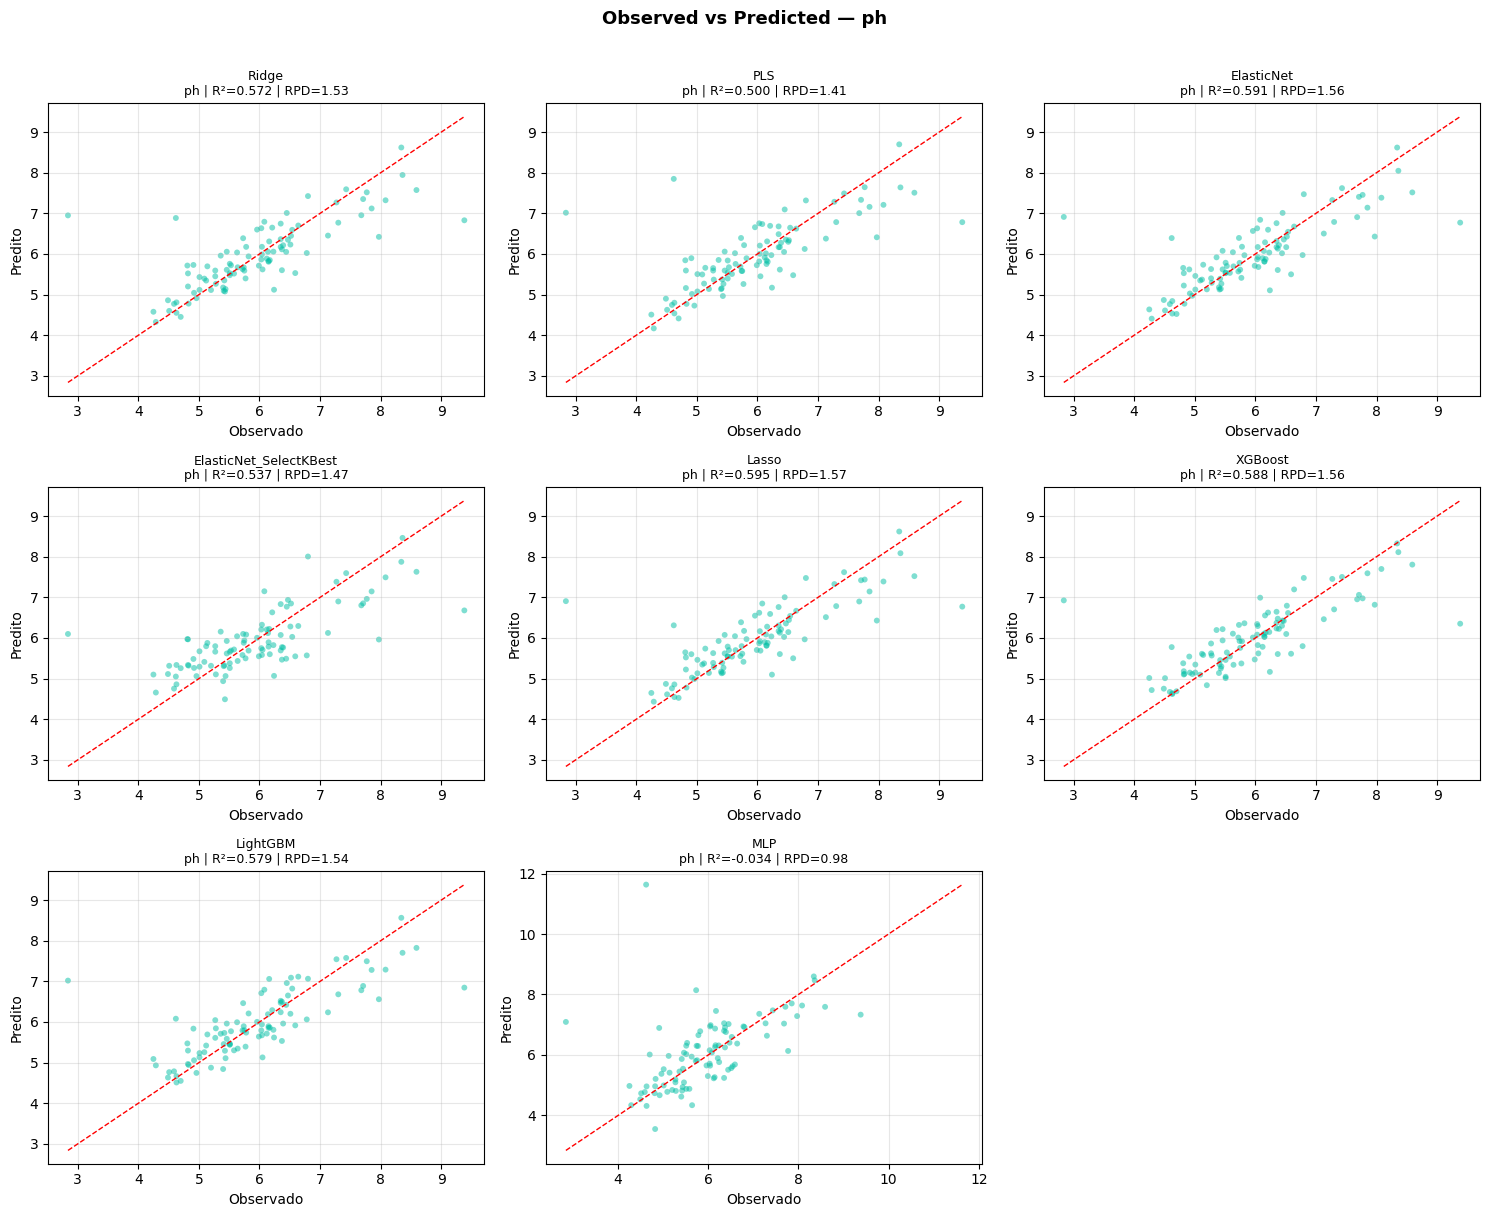

,modelo,target,log_transform,n_amostras,n_features_originais,cv_best_r2,test_r2,test_rmse,test_mae,test_rpd,pca_componentes,pca_variancia_explicada,k_best,melhores_params
0,Lasso,ph,False,472,2542,0.826313,0.594651,0.686416,0.418325,1.570672,61.0,0.998956,NaN,"{'pca_n_components': 61, 'alpha': 0.009555744901379065}"
1,ElasticNet,ph,False,472,2542,0.826576,0.591134,0.689388,0.419708,1.563901,62.0,0.998982,NaN,"{'pca_n_components': 62, 'alpha': 0.0184902504210113, 'l1_ratio': 0.4649649186951445}"
2,XGBoost,ph,False,472,2542,0.793125,0.588283,0.691787,0.423562,1.558477,45.0,0.998354,NaN,"{'pca_n_components': 45, 'n_estimators': 100, 'learning_rate': 0.15492869021196573, 'max_depth': 2, 'subsample': 0.7581412277959869, 'colsample_bytree': 0.9034143157512019, 'reg_alpha': 0.19876008171027174, 'reg_lambda': 1.8098259102802305}"
3,LightGBM,ph,False,472,2542,0.795192,0.578882,0.699640,0.452871,1.540983,66.0,0.999079,NaN,"{'pca_n_components': 66, 'n_estimators': 500, 'learning_rate': 0.14369475577038432, 'max_depth': 2, 'num_leaves': 28, 'subsample': 0.7956285164508804, 'colsample_bytree': 0.7688603025983461, 'reg_alpha': 0.0015948204924660365, 'reg_lambda': 0.052965457430055346}"
4,Ridge,ph,False,472,2542,0.825411,0.571719,0.705565,0.427094,1.528043,56.0,0.998806,NaN,"{'pca_n_components': 56, 'alpha': 36.20997621010221}"
5,ElasticNet_SelectKBest,ph,False,472,2542,0.643666,0.537487,0.733221,0.536574,1.470408,NaN,NaN,300.0,"{'k_best': 300, 'alpha': 0.004012829863525879, 'l1_ratio': 0.6018776318790771}"
6,PLS,ph,False,472,2542,0.819972,0.499754,0.762544,0.457695,1.413865,56.0,0.998806,NaN,"{'pca_n_components': 56, 'n_components': 12}"
7,MLP,ph,False,472,2542,0.334412,-0.034099,1.096362,0.644451,0.983375,75.0,0.999257,NaN,"{'pca_n_components': 75, 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.00013184300254599998, 'learning_rate_init': 0.005185923805384535}"


In [4]:
resultados_ph, modelos_ph, split_ph = avaliar_modelos_espectrais_optuna(
    df=df_gold_ph,
    target_col="ph",
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=False,
    n_jobs=1,
    verbose=1
)

resultados_ph


#### Modelagem - Carbono

Tunando Ridge...


Best trial: 73. Best value: 0.707336: 100%|██████████| 100/100 [01:24<00:00,  1.18it/s]


Tunando PLS...


Best trial: 13. Best value: 0.706042: 100%|██████████| 100/100 [29:57<00:00, 17.98s/it]  


Tunando ElasticNet...


...

Best trial: 82. Best value: 0.689112: 100%|██████████| 100/100 [02:32<00:00,  1.53s/it]


Tunando LightGBM...


Best trial: 91. Best value: 0.630897: 100%|██████████| 100/100 [00:52<00:00,  1.91it/s]


Tunando MLP...


Best trial: 19. Best value: 0.746202: 100%|██████████| 100/100 [02:42<00:00,  1.63s/it]


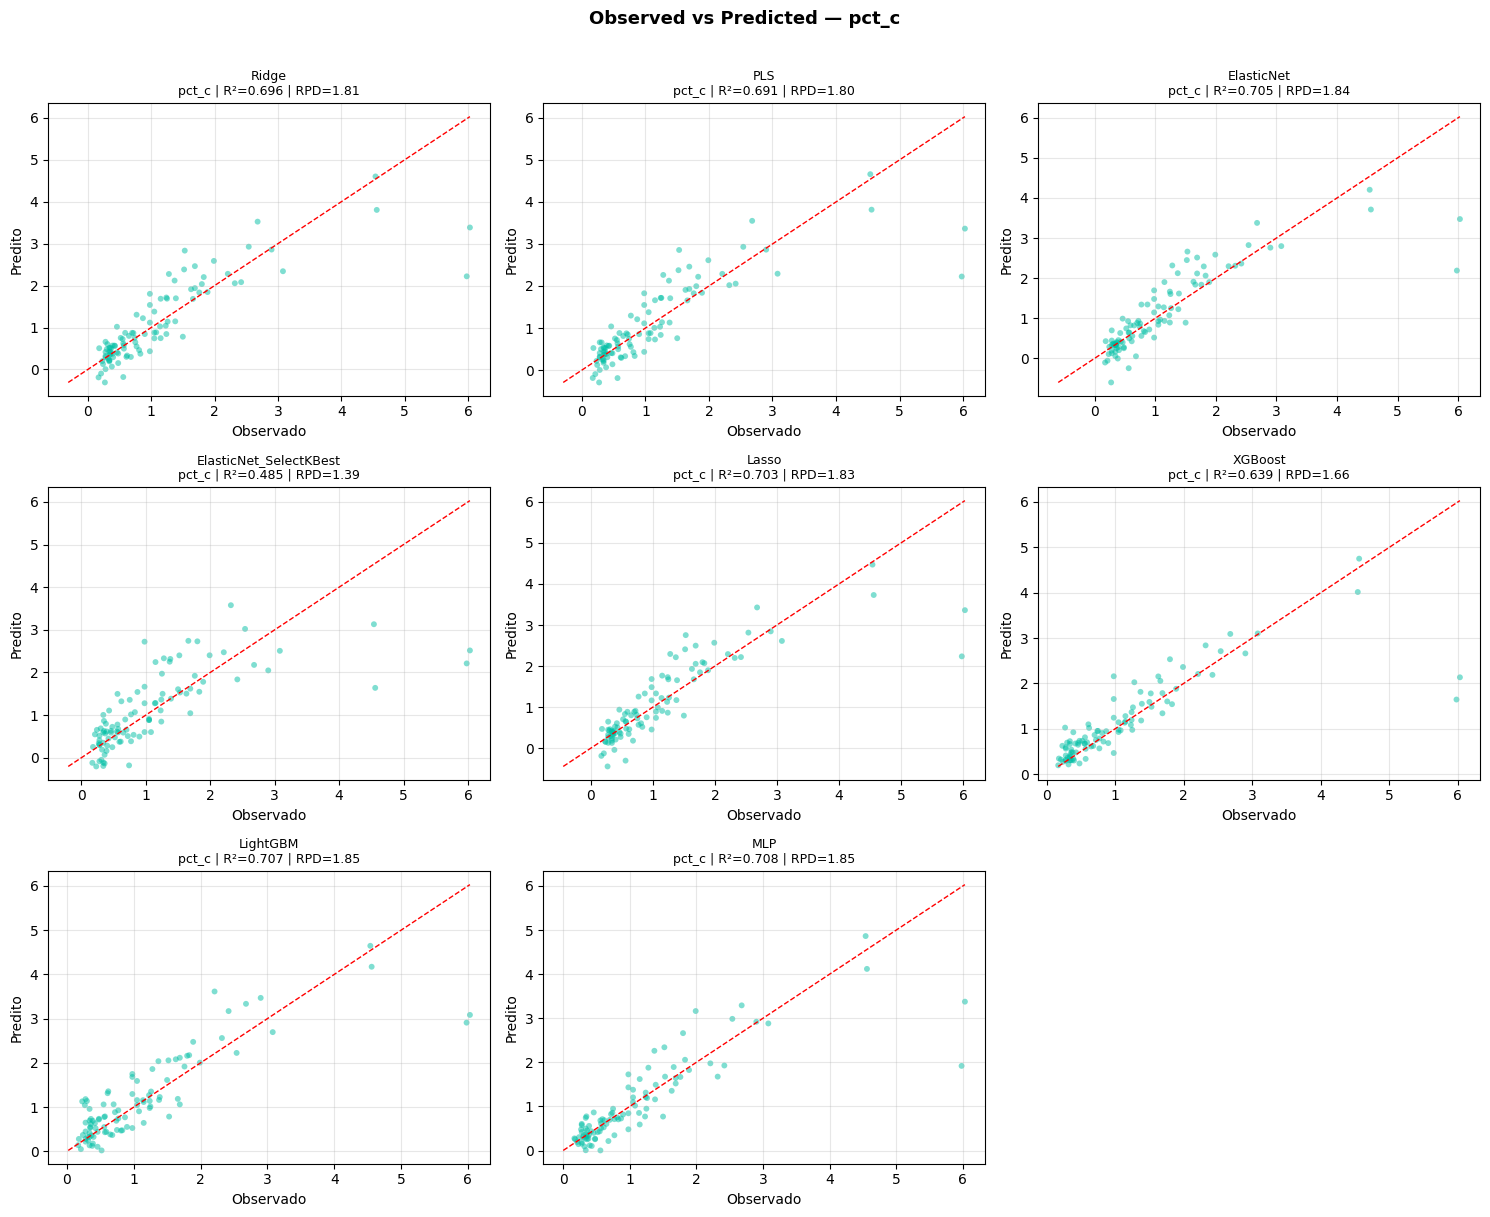

,modelo,target,log_transform,n_amostras,n_features_originais,cv_best_r2,test_r2,test_rmse,test_mae,test_rpd,pca_componentes,pca_variancia_explicada,k_best,melhores_params
0,MLP,pct_c,False,488,2542,0.746202,0.707544,0.591494,0.304672,1.849141,66.0,0.999108,NaN,"{'pca_n_components': 66, 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 7.132042230169393e-05, 'learning_rate_init': 0.007280093557869029}"
1,LightGBM,pct_c,False,488,2542,0.630897,0.707441,0.591599,0.371585,1.848813,10.0,0.982887,NaN,"{'pca_n_components': 10, 'n_estimators': 300, 'learning_rate': 0.04161985512122169, 'max_depth': 8, 'num_leaves': 47, 'subsample': 0.8583815076091388, 'colsample_bytree': 0.7734053472748053, 'reg_alpha': 0.0002499104764321192, 'reg_lambda': 0.008982176758775369}"
2,ElasticNet,pct_c,False,488,2542,0.713048,0.704613,0.594451,0.334012,1.839943,67.0,0.999132,NaN,"{'pca_n_components': 67, 'alpha': 0.01485187751108625, 'l1_ratio': 0.4008427456158712}"
3,Lasso,pct_c,False,488,2542,0.713637,0.702765,0.596308,0.337530,1.834214,68.0,0.999150,NaN,"{'pca_n_components': 68, 'alpha': 0.005317715775270483}"
4,Ridge,pct_c,False,488,2542,0.707336,0.695958,0.603098,0.353450,1.813564,68.0,0.999150,NaN,"{'pca_n_components': 68, 'alpha': 1.9032565421406793}"
5,PLS,pct_c,False,488,2542,0.706042,0.690996,0.607999,0.359815,1.798944,68.0,0.999150,NaN,"{'pca_n_components': 68, 'n_components': 2}"
6,XGBoost,pct_c,False,488,2542,0.689112,0.638578,0.657549,0.294719,1.663385,15.0,0.991642,NaN,"{'pca_n_components': 15, 'n_estimators': 400, 'learning_rate': 0.05260422656391007, 'max_depth': 5, 'subsample': 0.6112478508961379, 'colsample_bytree': 0.7110032952124675, 'reg_alpha': 0.0001422184720530654, 'reg_lambda': 0.020700198550323554}"
7,ElasticNet_SelectKBest,pct_c,False,488,2542,0.518067,0.484591,0.785229,0.480294,1.392913,NaN,NaN,266.0,"{'k_best': 266, 'alpha': 0.0006818992665918821, 'l1_ratio': 0.6070648590090875}"


In [5]:
resultados_carbono, modelos_carbono, split_carbono = avaliar_modelos_espectrais_optuna(
    df=df_gold_carbono,
    target_col="pct_c",
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=False,
    n_jobs=1,
    verbose=1
)

resultados_carbono


#### Modelagem - Fósforo

[log_transform] Aplicado log() em 'olsen_p_mg_kg'.
Tunando Ridge...


Best trial: 96. Best value: 0.428478: 100%|██████████| 100/100 [00:47<00:00,  2.12it/s]


Tunando PLS...


Best trial: 74. Best value: 0.417267: 100%|██████████| 100/100 [03:24<00:00,  2.04s/it] 


Tunando ElasticNet...


...

Best trial: 41. Best value: 0.406695: 100%|██████████| 100/100 [07:10<00:00,  4.30s/it]


Tunando LightGBM...


Best trial: 41. Best value: 0.39348: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


Tunando MLP...


Best trial: 81. Best value: 0.435137: 100%|██████████| 100/100 [02:30<00:00,  1.51s/it]


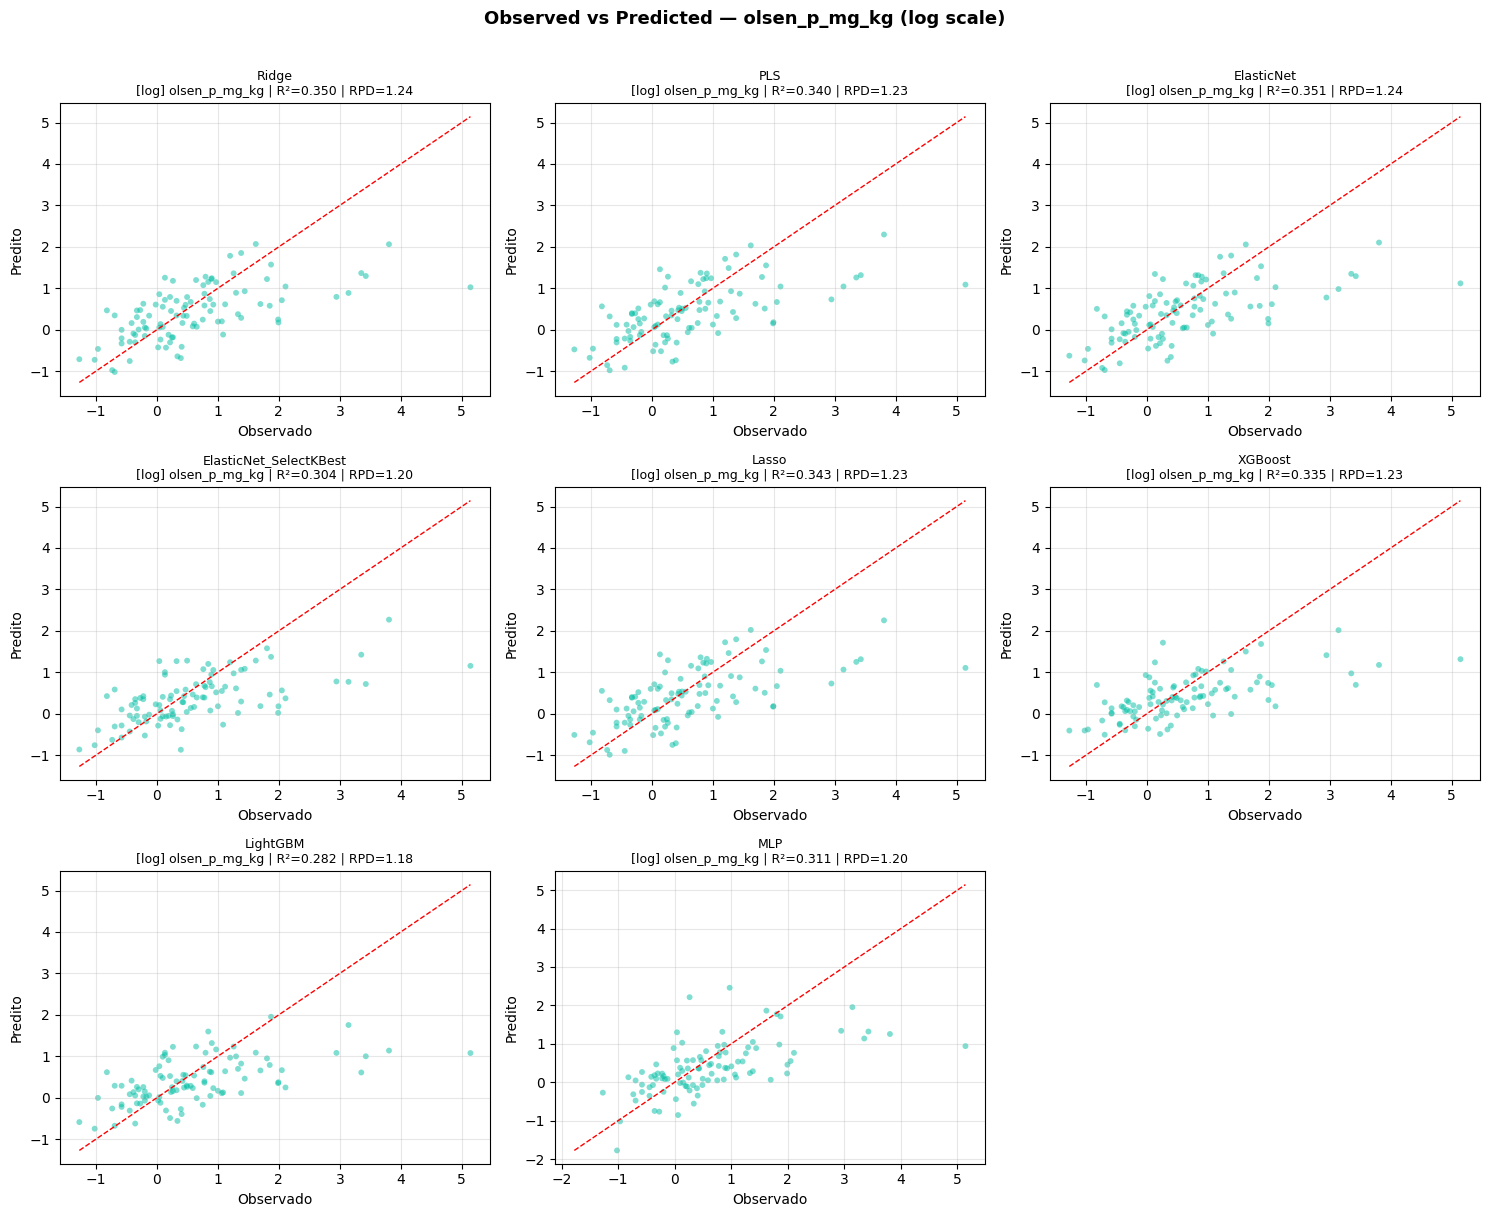

,modelo,target,log_transform,n_amostras,n_features_originais,cv_best_r2,test_r2,test_rmse,test_mae,test_rpd,pca_componentes,pca_variancia_explicada,k_best,melhores_params
0,ElasticNet,olsen_p_mg_kg,True,489,2542,0.421393,0.351218,0.877939,0.631505,1.241511,41.0,0.998130,NaN,"{'pca_n_components': 41, 'alpha': 0.060264935884220695, 'l1_ratio': 0.12169309225847065}"
1,Ridge,olsen_p_mg_kg,True,489,2542,0.428478,0.349580,0.879046,0.631834,1.239947,53.0,0.998716,NaN,"{'pca_n_components': 53, 'alpha': 73.35888307404284}"
2,Lasso,olsen_p_mg_kg,True,489,2542,0.417575,0.343208,0.883341,0.638650,1.233918,39.0,0.997995,NaN,"{'pca_n_components': 39, 'alpha': 0.002262135879568124}"
3,PLS,olsen_p_mg_kg,True,489,2542,0.417267,0.339998,0.885498,0.640324,1.230913,39.0,0.997995,NaN,"{'pca_n_components': 39, 'n_components': 14}"
4,XGBoost,olsen_p_mg_kg,True,489,2542,0.406695,0.335213,0.888701,0.623885,1.226476,38.0,0.997924,NaN,"{'pca_n_components': 38, 'n_estimators': 300, 'learning_rate': 0.03204440824656043, 'max_depth': 6, 'subsample': 0.6279900584935664, 'colsample_bytree': 0.8295977408874127, 'reg_alpha': 0.009487644168489238, 'reg_lambda': 1.062115914164571}"
5,MLP,olsen_p_mg_kg,True,489,2542,0.435137,0.311021,0.904728,0.645121,1.204750,66.0,0.999087,NaN,"{'pca_n_components': 66, 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.022809234742588013, 'learning_rate_init': 0.0072916440279190645}"
6,ElasticNet_SelectKBest,olsen_p_mg_kg,True,489,2542,0.331438,0.304410,0.909058,0.617900,1.199012,NaN,NaN,294.0,"{'k_best': 294, 'alpha': 0.005180022974785153, 'l1_ratio': 0.06876378126521843}"
7,LightGBM,olsen_p_mg_kg,True,489,2542,0.393480,0.282001,0.923585,0.653912,1.180153,39.0,0.997995,NaN,"{'pca_n_components': 39, 'n_estimators': 200, 'learning_rate': 0.05594963274607431, 'max_depth': 3, 'num_leaves': 61, 'subsample': 0.7681183883166284, 'colsample_bytree': 0.9702919817699758, 'reg_alpha': 3.6527595680848117, 'reg_lambda': 0.0016099781660140996}"


In [6]:
# Fósforo: log_transform=True para lidar com distribuição assimétrica
# As métricas (R², RMSE, MAE, RPD) são calculadas no espaço log
# Para interpretar RMSE em unidades originais: np.expm1(pred) - np.expm1(obs)
resultados_p, modelos_p, split_p = avaliar_modelos_espectrais_optuna(
    df=df_gold_fosforo,
    target_col="olsen_p_mg_kg",
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=True,
    n_jobs=1,
    verbose=1
)

resultados_p


#### Modelagem - ECEC

Tunando Ridge...


Best trial: 60. Best value: 0.783743: 100%|██████████| 100/100 [51:59<00:00, 31.19s/it]   


Tunando PLS...


Best trial: 54. Best value: 0.782932: 100%|██████████| 100/100 [00:45<00:00,  2.18it/s]


Tunando ElasticNet...


...

Best trial: 83. Best value: 0.783271: 100%|██████████| 100/100 [03:32<00:00,  2.12s/it]


Tunando LightGBM...


Best trial: 94. Best value: 0.764125: 100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


Tunando MLP...


Best trial: 75. Best value: 0.830615: 100%|██████████| 100/100 [02:24<00:00,  1.44s/it]


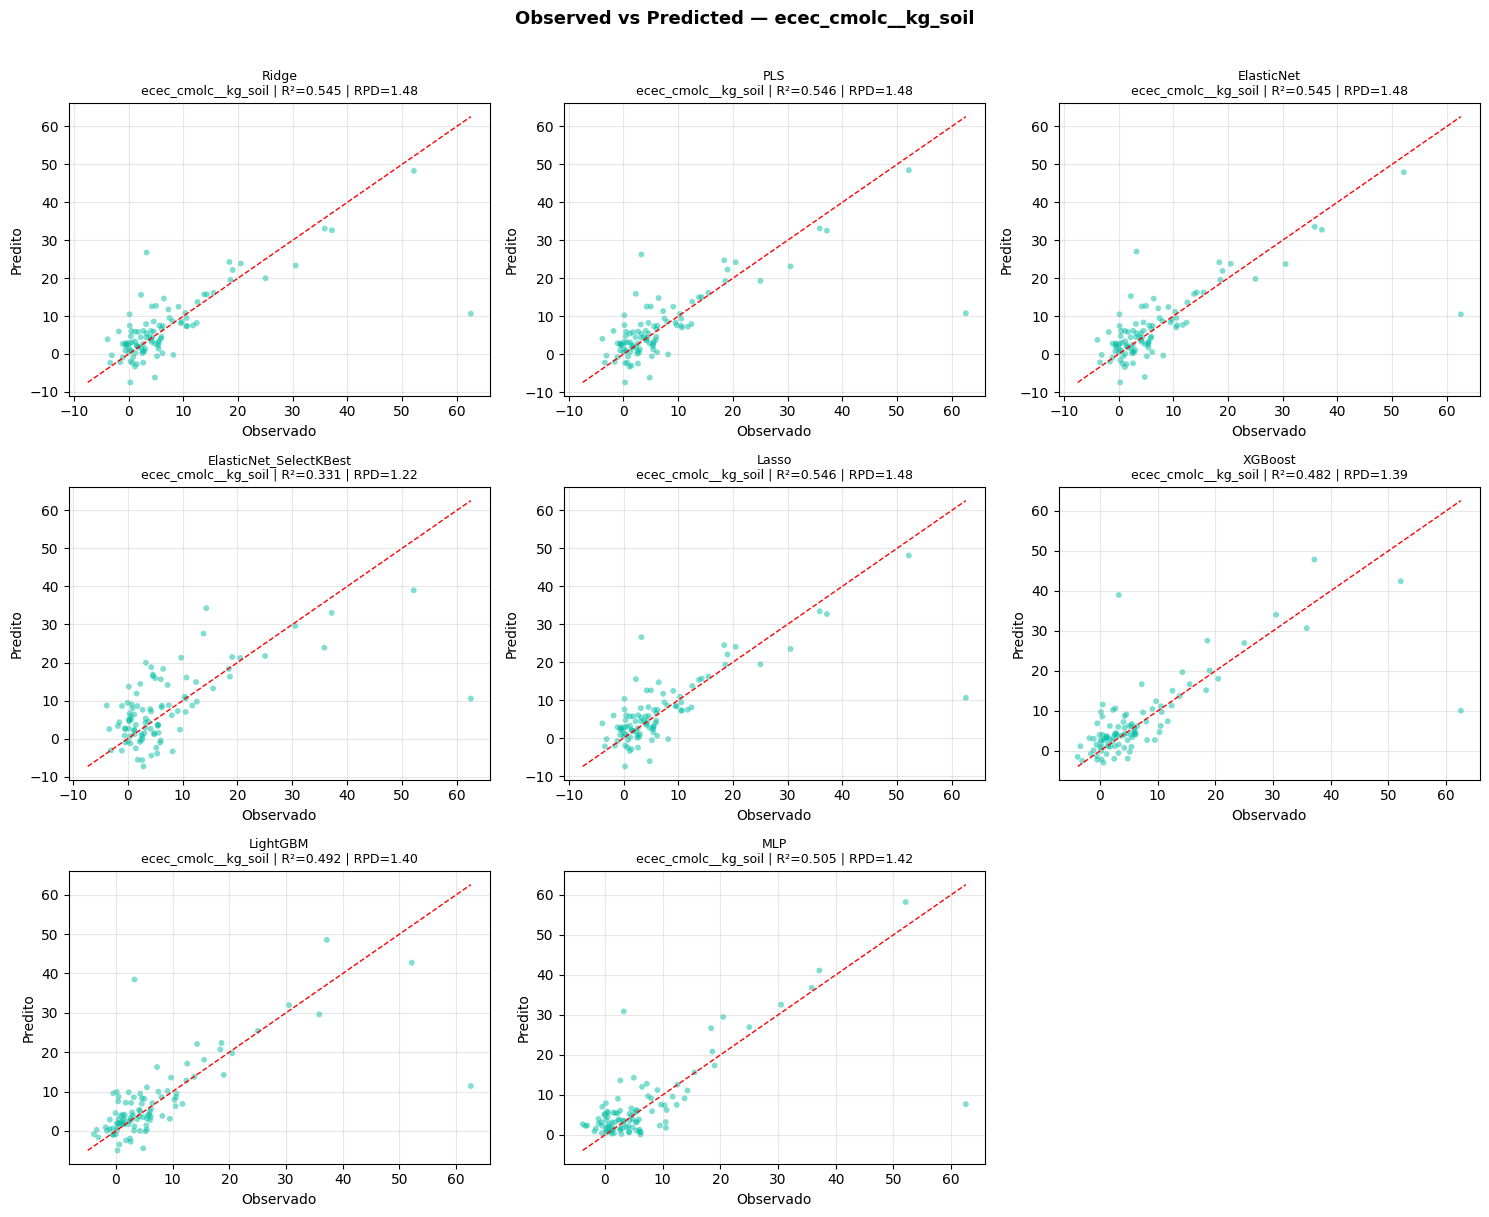

,modelo,target,log_transform,n_amostras,n_features_originais,cv_best_r2,test_r2,test_rmse,test_mae,test_rpd,pca_componentes,pca_variancia_explicada,k_best,melhores_params
0,Lasso,ecec_cmolc__kg_soil,False,489,2542,0.784483,0.546144,7.056502,3.876416,1.484366,55.0,0.998788,NaN,"{'pca_n_components': 55, 'alpha': 0.017157471059421926}"
1,PLS,ecec_cmolc__kg_soil,False,489,2542,0.782932,0.545854,7.058758,3.895298,1.483892,55.0,0.998788,NaN,"{'pca_n_components': 55, 'n_components': 18}"
2,Ridge,ecec_cmolc__kg_soil,False,489,2542,0.783743,0.545132,7.064365,3.888155,1.482714,55.0,0.998788,NaN,"{'pca_n_components': 55, 'alpha': 6.711857331597351}"
3,ElasticNet,ecec_cmolc__kg_soil,False,489,2542,0.784877,0.544809,7.066873,3.872256,1.482188,55.0,0.998788,NaN,"{'pca_n_components': 55, 'alpha': 0.03278694279911969, 'l1_ratio': 0.7481465341598608}"
4,MLP,ecec_cmolc__kg_soil,False,489,2542,0.830615,0.504818,7.370769,3.947246,1.421077,54.0,0.998753,NaN,"{'pca_n_components': 54, 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 3.2081159017371834e-05, 'learning_rate_init': 0.00883280619088615}"
5,LightGBM,ecec_cmolc__kg_soil,False,489,2542,0.764125,0.492183,7.464215,3.955531,1.403286,12.0,0.987052,NaN,"{'pca_n_components': 12, 'n_estimators': 500, 'learning_rate': 0.08517721332790706, 'max_depth': 4, 'num_leaves': 17, 'subsample': 0.6901031515869189, 'colsample_bytree': 0.8544627560629307, 'reg_alpha': 0.7730691376333948, 'reg_lambda': 0.0002970583021840669}"
6,XGBoost,ecec_cmolc__kg_soil,False,489,2542,0.783271,0.482262,7.536772,3.840009,1.389777,13.0,0.988654,NaN,"{'pca_n_components': 13, 'n_estimators': 500, 'learning_rate': 0.0812579473729412, 'max_depth': 3, 'subsample': 0.7265761926542129, 'colsample_bytree': 0.9471597635182014, 'reg_alpha': 0.00030648340894924965, 'reg_lambda': 4.4601101205751}"
7,ElasticNet_SelectKBest,ecec_cmolc__kg_soil,False,489,2542,0.611680,0.330855,8.568223,5.691095,1.222474,NaN,NaN,300.0,"{'k_best': 300, 'alpha': 0.005558788549908361, 'l1_ratio': 0.7786867603533778}"


In [7]:
resultados_ecec, modelos_ecec, split_ecec = avaliar_modelos_espectrais_optuna(
    df=df_gold_ecec,
    target_col="ecec_cmolc__kg_soil",
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=False,
    n_jobs=1,
    verbose=1
)

resultados_ecec


#### Modelagem - ExBas

Tunando Ridge...


Best trial: 73. Best value: 0.851251: 100%|██████████| 100/100 [02:08<00:00,  1.29s/it]


Tunando PLS...


Best trial: 79. Best value: 0.845962: 100%|██████████| 100/100 [01:49<00:00,  1.09s/it]


Tunando ElasticNet...


...

Best trial: 72. Best value: 0.865961: 100%|██████████| 100/100 [12:34<00:00,  7.55s/it]


Tunando LightGBM...


Best trial: 87. Best value: 0.86334: 100%|██████████| 100/100 [1:29:18<00:00, 53.59s/it]   


Tunando MLP...


Best trial: 83. Best value: 0.882663: 100%|██████████| 100/100 [10:55<00:00,  6.56s/it]


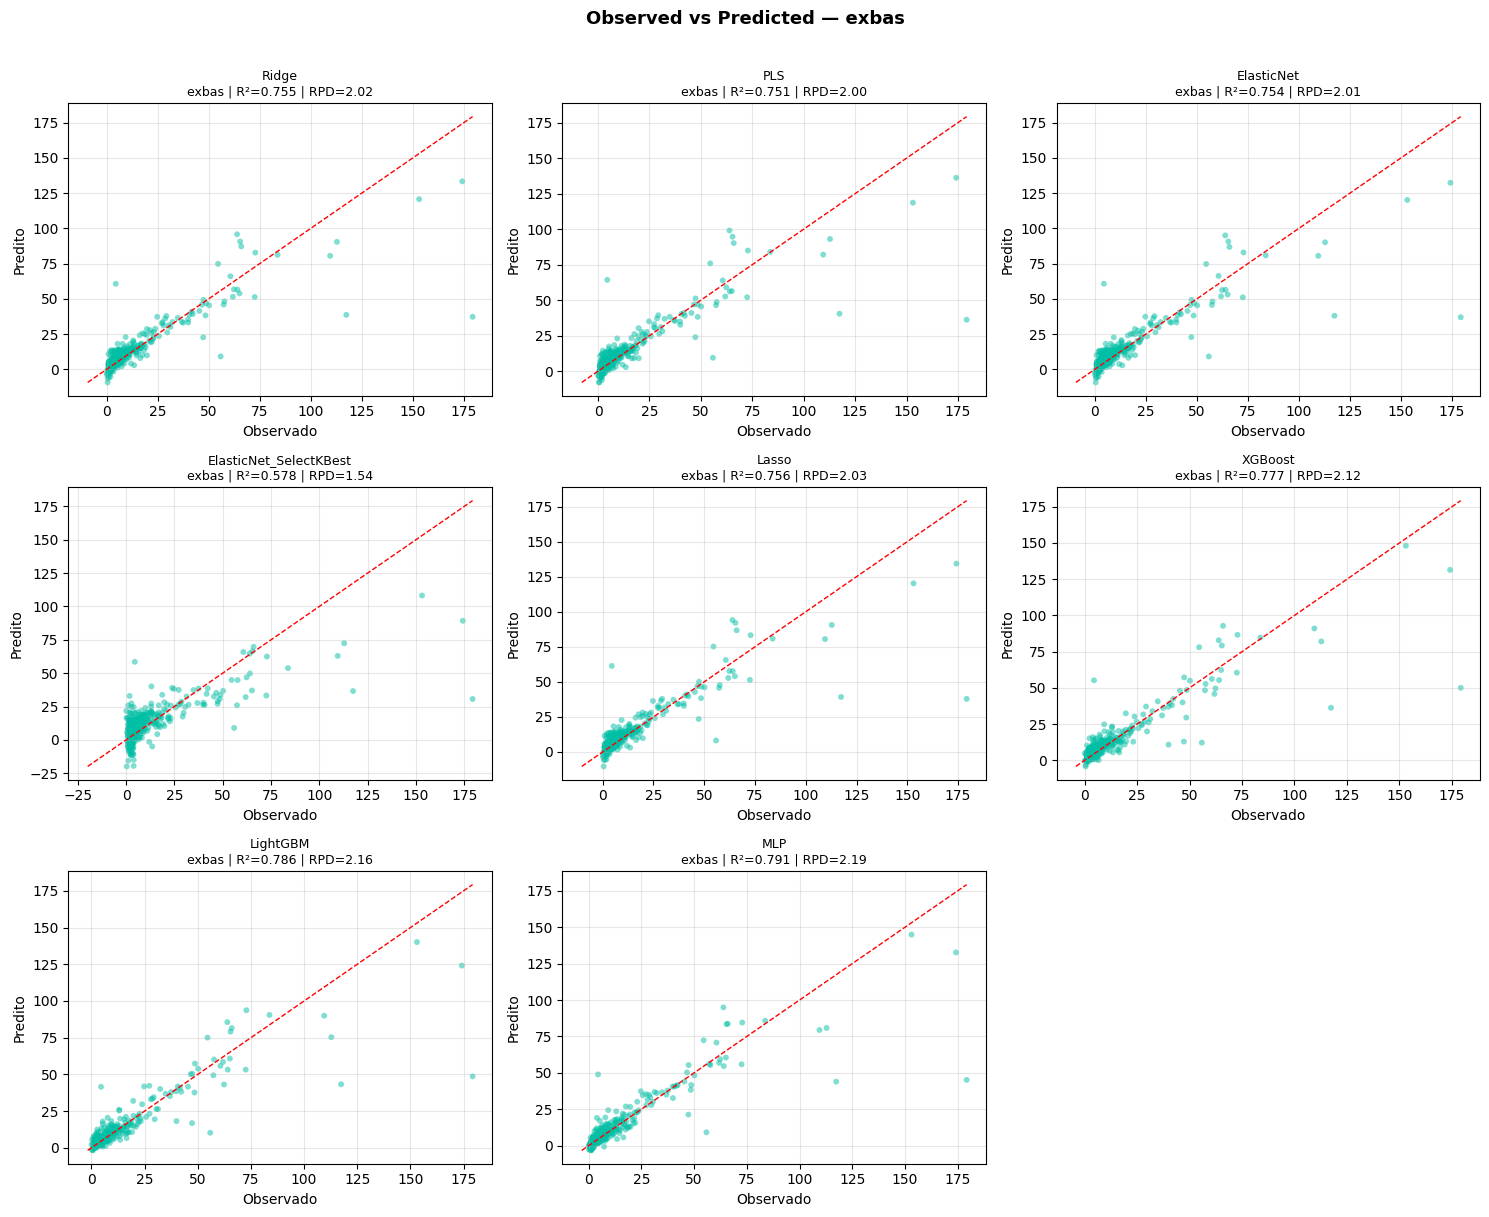

,modelo,target,log_transform,n_amostras,n_features_originais,cv_best_r2,test_r2,test_rmse,test_mae,test_rpd,pca_componentes,pca_variancia_explicada,k_best,melhores_params
0,MLP,exbas,False,1884,2542,0.882663,0.791321,10.116815,3.729946,2.189075,73.0,0.999198,NaN,"{'pca_n_components': 73, 'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 2.3370157678753465e-05, 'learning_rate_init': 0.0003612514599108766}"
1,LightGBM,exbas,False,1884,2542,0.863340,0.786369,10.236144,4.062038,2.163555,23.0,0.996003,NaN,"{'pca_n_components': 23, 'n_estimators': 400, 'learning_rate': 0.048991808700684404, 'max_depth': 7, 'num_leaves': 17, 'subsample': 0.8674688209579952, 'colsample_bytree': 0.6378232116782394, 'reg_alpha': 0.000593215305170006, 'reg_lambda': 0.00032456328558057854}"
2,XGBoost,exbas,False,1884,2542,0.865961,0.776958,10.459172,4.311069,2.117420,33.0,0.997624,NaN,"{'pca_n_components': 33, 'n_estimators': 400, 'learning_rate': 0.1163880371323018, 'max_depth': 3, 'subsample': 0.7262126450245521, 'colsample_bytree': 0.9572602322749496, 'reg_alpha': 0.003367202810981426, 'reg_lambda': 9.60411804675764}"
3,Lasso,exbas,False,1884,2542,0.849614,0.756416,10.930218,4.434766,2.026169,80.0,0.999299,NaN,"{'pca_n_components': 80, 'alpha': 0.0994065587658175}"
4,Ridge,exbas,False,1884,2542,0.851251,0.755210,10.957245,4.404371,2.021171,75.0,0.999229,NaN,"{'pca_n_components': 75, 'alpha': 149.61027378798005}"
5,ElasticNet,exbas,False,1884,2542,0.851199,0.753514,10.995125,4.421753,2.014208,76.0,0.999244,NaN,"{'pca_n_components': 76, 'alpha': 0.1324813114701144, 'l1_ratio': 0.08485267996506463}"
6,PLS,exbas,False,1884,2542,0.845962,0.750529,11.061517,4.530180,2.002118,45.0,0.998421,NaN,"{'pca_n_components': 45, 'n_components': 19}"
7,ElasticNet_SelectKBest,exbas,False,1884,2542,0.640139,0.578160,14.383961,8.309537,1.539664,NaN,NaN,300.0,"{'k_best': 300, 'alpha': 0.007210328588817169, 'l1_ratio': 0.5463676186940057}"


In [8]:
resultados_exbas, modelos_exbas, split_exbas = avaliar_modelos_espectrais_optuna(
    df=df_gold_exbas,
    target_col="exbas",
    feature_prefix="wn_",
    test_size=0.2,
    random_state=42,
    cv_splits=5,
    n_trials=100,
    log_transform=False,
    n_jobs=1,
    verbose=1
)

resultados_exbas


#### Salvando resultados

In [16]:
import boto3
from datetime import datetime
import io

# Cliente S3
s3 = boto3.client("s3")

BUCKET = "projeto-edb-015"
BASE_PREFIX = "results"

# Timestamp
timestamp = datetime.utcnow().strftime("%Y-%m-%d_%H-%M-%S")


def salvar_csv_s3(df, target_name):
    """
    df: DataFrame (pandas)
    target_name: ex: 'ph', 'carbono', etc
    """

    # Nome do arquivo
    file_name = f"resultados_{target_name}_{timestamp}.csv"

    # Caminho S3
    s3_key = f"{BASE_PREFIX}/{target_name}/{file_name}"

    # Converter DataFrame para CSV em memória
    csv_buffer = io.StringIO()
    df.to_csv(csv_buffer, index=False)

    # Upload
    s3.put_object(
        Bucket=BUCKET,
        Key=s3_key,
        Body=csv_buffer.getvalue().encode("utf-8"),
        ContentType="text/csv"
    )

    print(f"Salvo em: s3://{BUCKET}/{s3_key}")


salvar_csv_s3(resultados_ph, "ph")
salvar_csv_s3(resultados_carbono, "carbono")
salvar_csv_s3(resultados_p, "p")
salvar_csv_s3(resultados_ecec, "ecec")
salvar_csv_s3(resultados_exbas, "exbas")

AccessDenied: An error occurred (AccessDenied) when calling the PutObject operation: User: arn:aws:sts::590183838075:assumed-role/voclabs/user4284940=__rika_Carvalho_de_Aquino is not authorized to perform: s3:PutObject on resource: "arn:aws:s3:::projeto-edb-015/results/ph/resultados_ph_2026-05-10_01-51-26.csv" with an explicit deny in an identity-based policy

In [18]:
path = r'C:\Users\ahmad\Documents\USP\MBA - Engenharia de Dados e Big Data\Projeto Integrador - eEDB-015\Projeto'
os.chdir(path)

resultados_ph.to_csv('resultados_ph_'+timestamp+'.csv')
resultados_carbono.to_csv('resultados_carbono_'+timestamp+'.csv')
resultados_p.to_csv('resultados_p_'+timestamp+'.csv')
resultados_ecec.to_csv('resultados_ecec_'+timestamp+'.csv')
resultados_exbas.to_csv('resultados_exbas_'+timestamp+'.csv')